# 07 · Campaigns & Sources

**Goal:** compare campaign effectiveness (lead generation and conversion), assess marketing sources by lead quality, and analyze revenue by campaign.

In [20]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

In [21]:
DATA_PROCESSED = Path('../data/processed')
deals = pd.read_parquet(DATA_PROCESSED / 'deals_clean.parquet')

## 1. Campaign performance — lead generation and conversion rate

In [22]:
# Per-campaign stats
campaign_stats = deals.groupby('Campaign').agg(
    leads=('Id', 'count'),
    won=('is_won_confirmed', 'sum'),
    lost=('Stage_Group', lambda x: (x == 'Lost').sum())
).round(0)

campaign_stats['cr_closed_%'] = (
    campaign_stats['won'] / (campaign_stats['won'] + campaign_stats['lost']) * 100
).round(2)

print(f"campaign_stats created: {len(campaign_stats)} campaigns")
print(campaign_stats.head())

Создано campaign_stats: 154 кампаний
                      leads  won  lost  cr_closed_%
Campaign                                           
01.04.23women_PL         31    0    27         0.00
02.05.24test_DE         121    1    47         2.08
02.07.23wide_DE         975   52   781         6.24
02.08.23interests_DE      8    0     8         0.00
03.07.23women           612   30   474         5.95


In [23]:
print(f"Total deals: {len(deals)}")
print(f"Deals with Campaign filled: {deals['Campaign'].notna().sum()}")
print(f"Deals with NaN Campaign: {deals['Campaign'].isna().sum()}")
print(f"Unique campaigns: {deals['Campaign'].nunique()}")

print("\n=== Top-20 campaigns by lead count ===")
top_campaigns = deals['Campaign'].value_counts(dropna=False).head(20)
print(top_campaigns)

print("\n=== Source distribution for deals with NaN Campaign ===")
nan_campaign_sources = (
    deals.loc[deals['Campaign'].isna(), 'Source']
    .value_counts(dropna=False)
)
print(nan_campaign_sources)

Всего сделок: 21593
Сделок с заполненным Campaign: 16067
Сделок с NaN Campaign: 5526
Уникальных Campaign: 154

=== Топ-20 кампаний по числу лидов ===
Campaign
NaN                                  5526
performancemax_digitalmarkt_ru_DE    2653
youtube_shorts_DE                    1635
12.07.2023wide_DE                    1575
02.07.23wide_DE                       975
04.07.23recentlymoved_DE              750
03.07.23women                         612
Dis_DE                                581
07.07.23LAL_DE                        542
12.09.23interests_Uxui_DE             531
24.09.23retargeting_DE                479
webinar1604                           343
work_DE                               317
webinar1906                           290
08.04.24wide_webinar_DE               284
blog2_DE                              273
1performancemax_wide_PL               261
BloggerShina_DE                       246
performancemax_eng_DE                 245
brand_search_eng_DE                   168
N

In [24]:
utm_fields = ['Campaign', 'Content', 'Term', 'Page']

# For deals with NaN Campaign — how many have other UTM fields filled
no_campaign = deals[deals['Campaign'].isna() | (deals['Campaign'] == 'No Campaign')]

print(f"Deals without Campaign: {len(no_campaign)}\n")
print("Of them, filled:")
for field in utm_fields:
    filled = no_campaign[field].notna().sum()
    print(f"  {field}: {filled} ({filled/len(no_campaign)*100:.1f}%)")

Сделок без Campaign: 5526

Из них имеют заполненные:
  Campaign: 0 (0.0%)
  Content: 522 (9.4%)
  Term: 840 (15.2%)
  Page: 5526 (100.0%)


Fill NaN Campaign with "No Campaign". Look at the overall distribution of leads per campaign.

In [25]:
deals['Campaign'] = deals['Campaign'].fillna('No Campaign')

Campaigns by lead count:

In [26]:
bins = [0, 30, 50, 100, float('inf')]
labels = ['< 30', '30–49', '50–99', '≥ 100']

campaign_stats['size_bucket'] = pd.cut(
    campaign_stats['leads'], bins=bins, labels=labels, right=False
)

bucket_counts = campaign_stats['size_bucket'].value_counts().sort_index()
bucket_share = (bucket_counts / len(campaign_stats) * 100).round(1)

print("Campaign distribution by lead volume:")
print(pd.DataFrame({'count': bucket_counts, 'share_%': bucket_share}))

Распределение кампаний по объёму лидов:
             count  share_%
size_bucket                
< 30           102     66.2
30–49           16     10.4
50–99            6      3.9
≥ 100           30     19.5


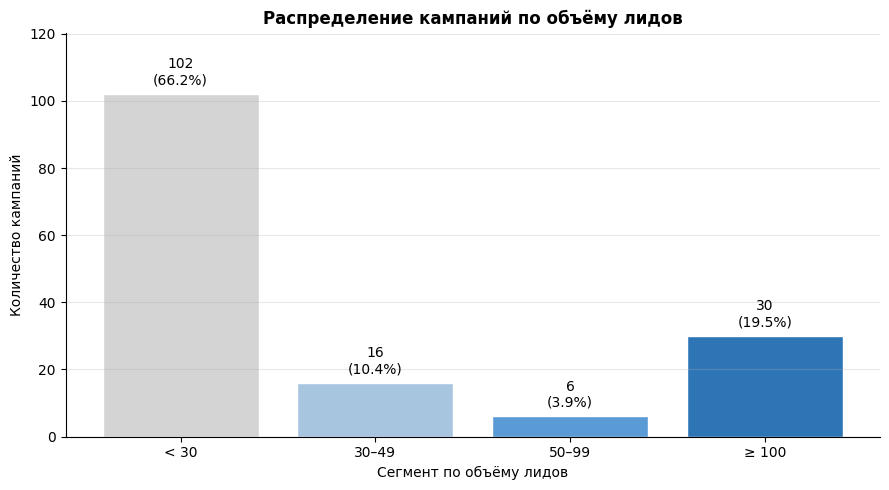

In [27]:
bucket_data = pd.DataFrame({'count': bucket_counts, 'share_%': bucket_share})

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(bucket_data.index.astype(str), bucket_data['count'],
              color=['#d4d4d4', '#a8c5e0', '#5b9bd5', '#2e75b6'], edgecolor='white')

# Labels: count + share
for bar, count, share in zip(bars, bucket_data['count'], bucket_data['share_%']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
            f'{count}\n({share}%)', ha='center', va='bottom', fontsize=10)

ax.set_xlabel('Lead-volume bucket')
ax.set_ylabel('Number of campaigns')
ax.set_title('Campaign distribution by lead volume', fontweight='bold')
ax.set_ylim(0, bucket_data['count'].max() * 1.18)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Findings

Two-thirds of campaigns are small (under 30 leads) — likely experimental launches or tests. The main lead flow comes from 31 large campaigns (>=100 leads).

Сумма лидов по сегментам кампаний:
             leads  share_%
size_bucket                
< 30           876      5.5
30–49          608      3.8
50–99          414      2.6
≥ 100        14169     88.2


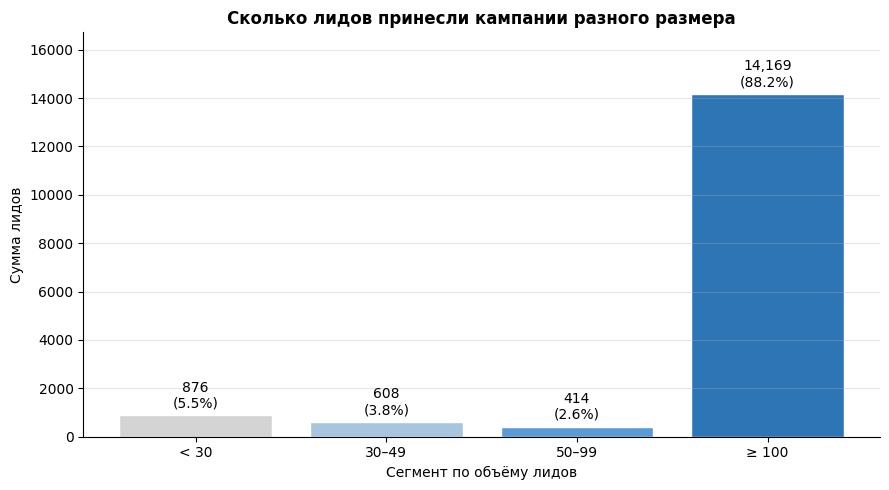

In [28]:
# Sum of leads per segment
bucket_leads = campaign_stats.groupby('size_bucket', observed=True)['leads'].sum()
total_leads = bucket_leads.sum()
bucket_leads_share = (bucket_leads / total_leads * 100).round(1)

print("Lead totals by campaign segment:")
print(pd.DataFrame({'leads': bucket_leads, 'share_%': bucket_leads_share}))

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(bucket_leads.index.astype(str), bucket_leads.values,
              color=['#d4d4d4', '#a8c5e0', '#5b9bd5', '#2e75b6'], edgecolor='white')
for bar, leads, share in zip(bars, bucket_leads, bucket_leads_share):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + total_leads * 0.012,
            f'{leads:,}\n({share}%)', ha='center', va='bottom', fontsize=10)
ax.set_xlabel('Lead-volume bucket')
ax.set_ylabel('Total leads')
ax.set_title('Leads brought by campaigns of different sizes', fontweight='bold')
ax.set_ylim(0, bucket_leads.max() * 1.18)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### Findings

20% of campaigns generate 91% of all leads. The other 80% together bring under 10%. Let's look at the top 15 of these 31 campaigns:

In [29]:
# Top-15 campaigns by volume, with CR
big_campaigns = (campaign_stats[campaign_stats['leads'] >= 100]
                 .sort_values('leads', ascending=False)
                 .head(15))

print("Top-15 large campaigns (>=100 leads):")
print(big_campaigns[['leads', 'won', 'lost', 'cr_closed_%']])

Топ-15 крупных кампаний (≥100 лидов):
                                   leads  won  lost  cr_closed_%
Campaign                                                        
performancemax_digitalmarkt_ru_DE   2653  109  2335         4.46
youtube_shorts_DE                   1635   53  1322         3.85
12.07.2023wide_DE                   1575   48  1314         3.52
02.07.23wide_DE                      975   52   781         6.24
04.07.23recentlymoved_DE             750   30   597         4.78
03.07.23women                        612   30   474         5.95
Dis_DE                               581   29   506         5.42
07.07.23LAL_DE                       542   28   377         6.91
12.09.23interests_Uxui_DE            531   26   421         5.82
24.09.23retargeting_DE               479   17   373         4.36
webinar1604                          343    3    29         9.38
work_DE                              317    9   254         3.42
webinar1906                          290    0     3 

### Findings

Over 6% of leads come from untracked campaigns. Partly a data-tracking improvement area, but this also includes Source categories that have no campaign by definition — Organic (2,589), SMM (1,335), CRM (557). Since the task is to analyze campaigns, "No Campaign" is excluded here and examined later in the Source section. Campaign analysis uses only filled campaign data.

Сумма лидов по сегментам кампаний (без No Campaign):
             leads  share_%
size_bucket                
< 30           876      5.5
30–49          608      3.8
50–99          414      2.6
≥ 100        14169     88.2


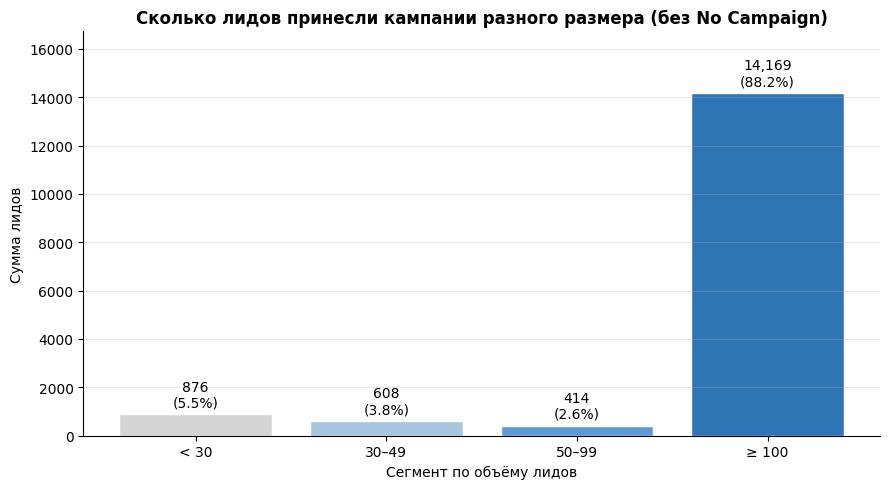

In [30]:
# Exclude No Campaign
stats_no_nc = campaign_stats[campaign_stats.index != 'No Campaign'].copy()

bins = [0, 30, 50, 100, float('inf')]
labels = ['< 30', '30–49', '50–99', '≥ 100']
stats_no_nc['size_bucket'] = pd.cut(
    stats_no_nc['leads'], bins=bins, labels=labels, right=False
)

bucket_leads = stats_no_nc.groupby('size_bucket', observed=True)['leads'].sum()
total_leads = bucket_leads.sum()
bucket_leads_share = (bucket_leads / total_leads * 100).round(1)

print("Lead totals by campaign segment (excl. No Campaign):")
print(pd.DataFrame({'leads': bucket_leads, 'share_%': bucket_leads_share}))

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(bucket_leads.index.astype(str), bucket_leads.values,
              color=['#d4d4d4', '#a8c5e0', '#5b9bd5', '#2e75b6'], edgecolor='white')
for bar, leads, share in zip(bars, bucket_leads, bucket_leads_share):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + total_leads * 0.012,
            f'{leads:,}\n({share}%)', ha='center', va='bottom', fontsize=10)
ax.set_xlabel('Lead-volume bucket')
ax.set_ylabel('Total leads')
ax.set_title('Leads by campaign size (excl. No Campaign)', fontweight='bold')
ax.set_ylim(0, bucket_leads.max() * 1.18)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [31]:
campaign_stats['closed'] = campaign_stats['won'] + campaign_stats['lost']
campaign_stats['closed_share_%'] = (
    campaign_stats['closed'] / campaign_stats['leads'] * 100
).round(1)

big_campaigns = (campaign_stats[
    (campaign_stats['leads'] >= 100)
    & (campaign_stats.index != 'No Campaign')
].sort_values('leads', ascending=False).head(15))

print("Top-15 large campaigns without 'No Campaign':")
print(big_campaigns[['leads', 'won', 'lost', 'closed_share_%', 'cr_closed_%']])

Топ-15 крупных кампаний без 'No Campaign':
                                   leads  won  lost  closed_share_%  \
Campaign                                                              
performancemax_digitalmarkt_ru_DE   2653  109  2335            92.1   
youtube_shorts_DE                   1635   53  1322            84.1   
12.07.2023wide_DE                   1575   48  1314            86.5   
02.07.23wide_DE                      975   52   781            85.4   
04.07.23recentlymoved_DE             750   30   597            83.6   
03.07.23women                        612   30   474            82.4   
Dis_DE                               581   29   506            92.1   
07.07.23LAL_DE                       542   28   377            74.7   
12.09.23interests_Uxui_DE            531   26   421            84.2   
24.09.23retargeting_DE               479   17   373            81.4   
webinar1604                          343    3    29             9.3   
work_DE                           

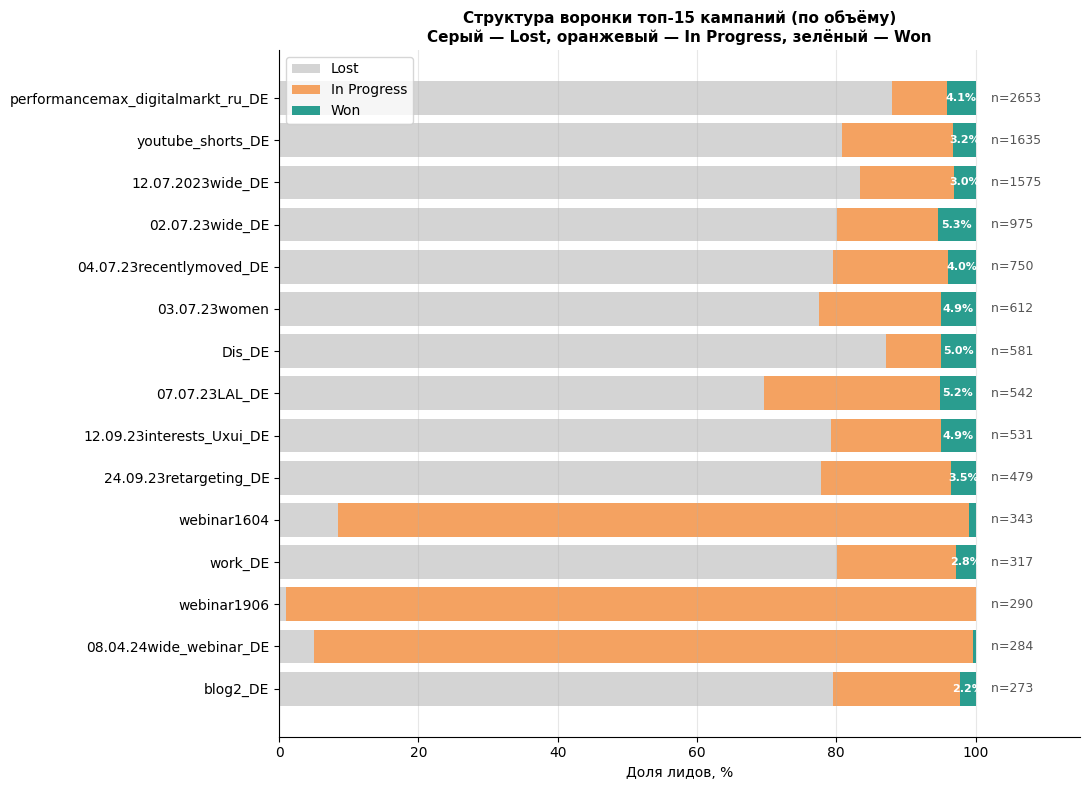

In [32]:
# Add in_progress column
campaign_stats['in_progress'] = (
    campaign_stats['leads'] - campaign_stats['won'] - campaign_stats['lost']
)

# Top-15 by volume without No Campaign, ascending for the chart (largest on top)
top15 = (campaign_stats[
    (campaign_stats['leads'] >= 100)
    & (campaign_stats.index != 'No Campaign')
].sort_values('leads', ascending=True).tail(15))

top15_pct = pd.DataFrame({
    'Won': top15['won'] / top15['leads'] * 100,
    'In Progress': top15['in_progress'] / top15['leads'] * 100,
    'Lost': top15['lost'] / top15['leads'] * 100,
})

fig, ax = plt.subplots(figsize=(11, 8))
bars_lost = ax.barh(top15_pct.index, top15_pct['Lost'], color='#d4d4d4', label='Lost')
bars_progress = ax.barh(top15_pct.index, top15_pct['In Progress'],
                        left=top15_pct['Lost'], color='#f4a261', label='In Progress')
bars_won = ax.barh(top15_pct.index, top15_pct['Won'],
                   left=top15_pct['Lost'] + top15_pct['In Progress'],
                   color='#2a9d8f', label='Won')

# Lead-volume label on the right
for i, (camp, row) in enumerate(top15.iterrows()):
    ax.text(101, i, f'  n={int(row["leads"])}', va='center', fontsize=9, color='#555')

# Won-share label inside green part (only if >= 2%)
for i, (camp, row) in enumerate(top15_pct.iterrows()):
    if row['Won'] >= 2:
        x_position = row['Lost'] + row['In Progress'] + row['Won']/2
        ax.text(x_position, i, f'{row["Won"]:.1f}%', ha='center', va='center',
                fontsize=8, color='white', fontweight='bold')

ax.set_xlabel('Share of leads, %')
ax.set_title('Funnel structure of top-15 campaigns (by volume)\n'
             'Gray — Lost, orange — In Progress, green — Won',
             fontsize=11, fontweight='bold')
ax.set_xlim(0, 115)
ax.legend(loc='upper left')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## Findings

Since raw conversion came out very low, the chart is built on shares — showing not only won deals but also fresh campaigns whose leads are still deciding. The chart illustrates this well: three large campaigns brought over 1,500 leads each, plus smaller ones. The two near the bottom are relatively fresh — most of their leads haven't decided yet. So judging only by conversion would miss the value of fresh campaigns.

Two complementary metrics are used in campaign analysis:

**CR_closed = Won / (Won + Lost)** — conversion on closed deals. Used for direct comparison of campaign effectiveness. Independent of lead freshness.

**CR_leads = Won / Total Leads** — share of Won among all campaign leads. Includes In Progress in the denominator — shows the actual result at the snapshot date. Understated for fresh campaigns.

### Top-15 campaigns by CR_closed

Зрелых крупных кампаний (≥100 лидов, ≥80% закрытых): 18

Топ по CR_closed:
                                   leads  won  lost  closed_share_%  \
Campaign                                                              
blog2_DE                             273    6   217            81.7   
work_DE                              317    9   254            83.0   
12.07.2023wide_DE                   1575   48  1314            86.5   
youtube_shorts_DE                   1635   53  1322            84.1   
15.07.23b_DE                         139    5   123            92.1   
24.09.23retargeting_DE               479   17   373            81.4   
performancemax_digitalmarkt_ru_DE   2653  109  2335            92.1   
04.07.23recentlymoved_DE             750   30   597            83.6   
Dis_DE                               581   29   506            92.1   
BloggerShina_DE                      246   11   189            81.3   
mu_DE                                151    7   119            83.4   
12

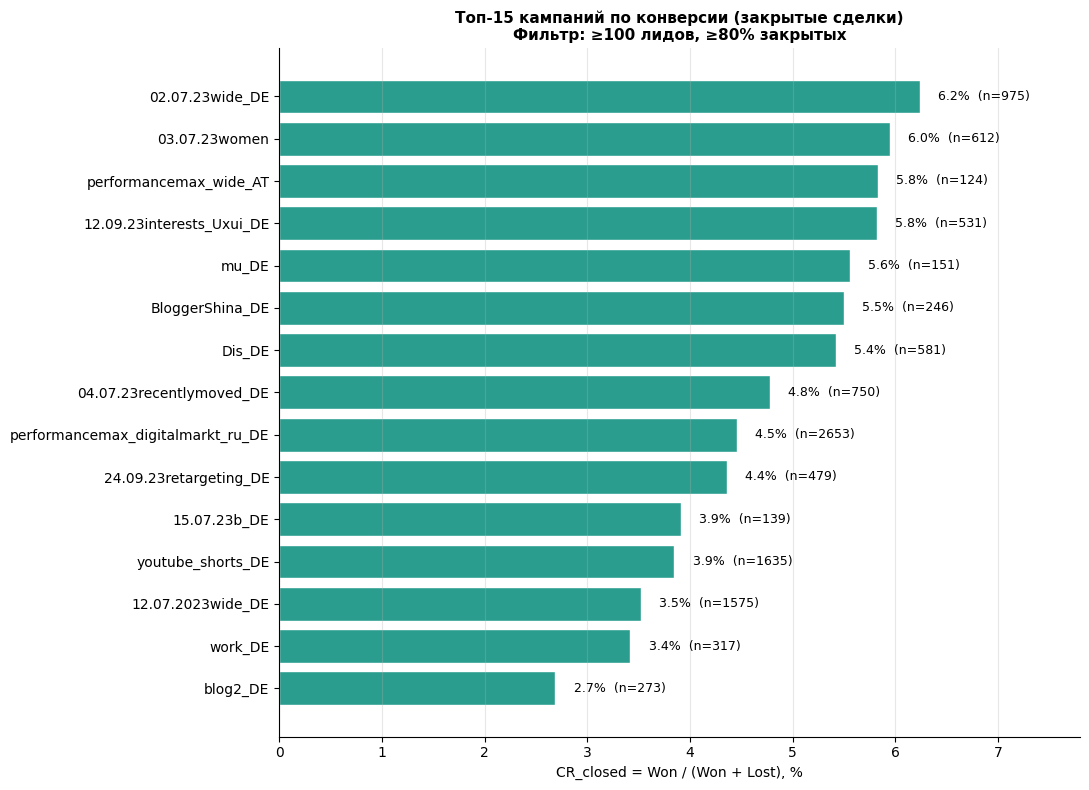

In [33]:
campaign_stats['closed'] = campaign_stats['won'] + campaign_stats['lost']
campaign_stats['closed_share_%'] = (
    campaign_stats['closed'] / campaign_stats['leads'] * 100
).round(1)

# Mature large campaigns
mature_big = campaign_stats[
    (campaign_stats['leads'] >= 100)
    & (campaign_stats['closed_share_%'] >= 80)
    & (campaign_stats.index != 'No Campaign')
].copy()

top_cr = mature_big.sort_values('cr_closed_%', ascending=True).tail(15)

print(f"Mature large campaigns (>=100 leads, >=80% closed): {len(mature_big)}")
print(f"\nTop by CR_closed:")
print(top_cr[['leads', 'won', 'lost', 'closed_share_%', 'cr_closed_%']])

fig, ax = plt.subplots(figsize=(11, 8))
bars = ax.barh(top_cr.index, top_cr['cr_closed_%'], color='#2a9d8f', edgecolor='white')
for i, (camp, row) in enumerate(top_cr.iterrows()):
    ax.text(row['cr_closed_%'] + 0.1, i,
            f'  {row["cr_closed_%"]:.1f}%  (n={int(row["leads"])})', va='center', fontsize=9)
ax.set_xlabel('CR_closed = Won / (Won + Lost), %')
ax.set_title('Top-15 campaigns by conversion (closed deals)\nFilter: >=100 leads, >=80% closed',
             fontsize=11, fontweight='bold')
ax.set_xlim(0, top_cr['cr_closed_%'].max() * 1.25)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

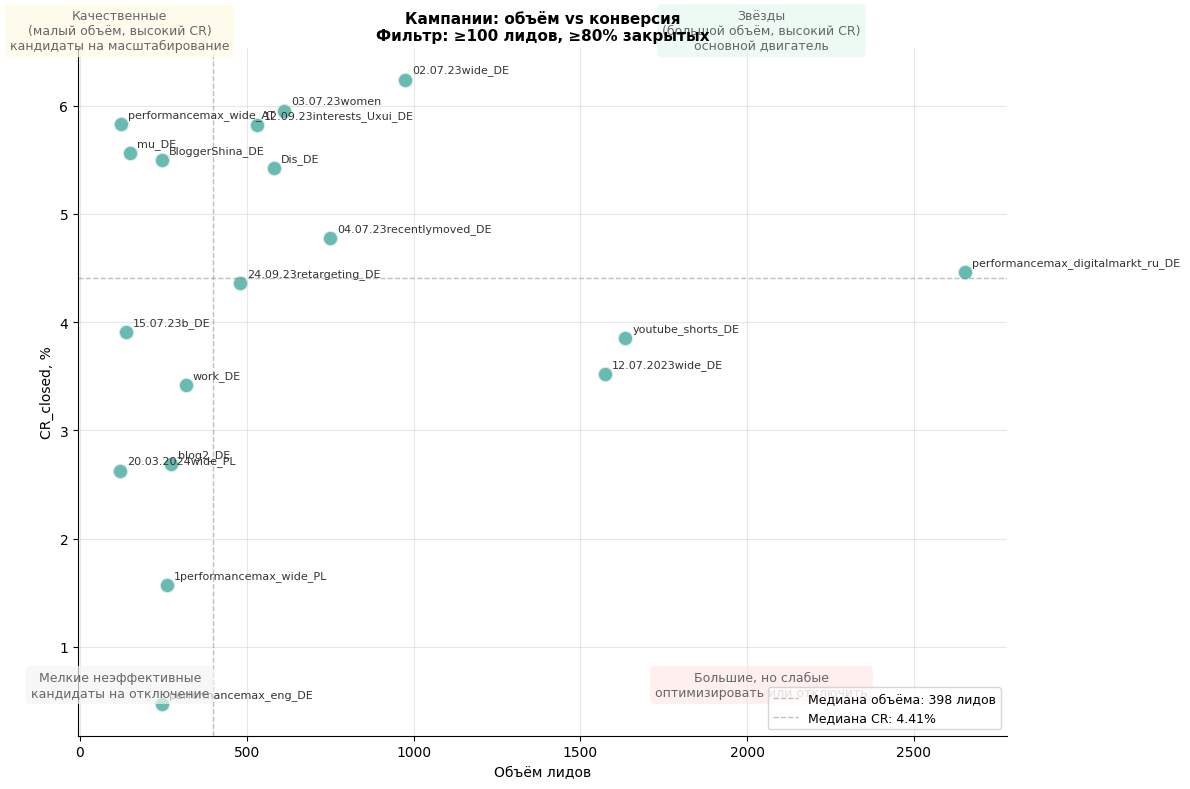

In [34]:
mature_big = campaign_stats[
    (campaign_stats['leads'] >= 100)
    & (campaign_stats['closed_share_%'] >= 80)
    & (campaign_stats.index != 'No Campaign')
].copy()

median_leads = mature_big['leads'].median()
median_cr = mature_big['cr_closed_%'].median()

fig, ax = plt.subplots(figsize=(12, 8))
ax.scatter(mature_big['leads'], mature_big['cr_closed_%'],
           s=120, alpha=0.7, color='#2a9d8f', edgecolor='white', linewidth=1.5)

for camp, row in mature_big.iterrows():
    ax.annotate(camp, (row['leads'], row['cr_closed_%']),
                xytext=(5, 5), textcoords='offset points', fontsize=8, color='#333')

ax.axvline(median_leads, color='gray', linestyle='--', linewidth=1, alpha=0.5,
           label=f'Median volume: {median_leads:.0f} leads')
ax.axhline(median_cr, color='gray', linestyle='--', linewidth=1, alpha=0.5,
           label=f'Median CR: {median_cr:.2f}%')

xmax = mature_big['leads'].max() * 1.1
ymax = mature_big['cr_closed_%'].max() * 1.1

ax.text(median_leads * 0.3, ymax * 0.95,
        'Quality\n(low volume, high CR)\nscaling candidates',
        fontsize=9, color='#666', ha='center',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='#fffce6', edgecolor='none', alpha=0.7))
ax.text(xmax * 0.7, ymax * 0.95,
        'Stars\n(high volume, high CR)\nmain driver',
        fontsize=9, color='#666', ha='center',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='#e6f7ee', edgecolor='none', alpha=0.7))
ax.text(median_leads * 0.3, ymax * 0.08,
        'Small & weak\nshut-down candidates',
        fontsize=9, color='#666', ha='center',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='#f5f5f5', edgecolor='none', alpha=0.7))
ax.text(xmax * 0.7, ymax * 0.08,
        'Large but weak\noptimize or shut down',
        fontsize=9, color='#666', ha='center',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='#ffe9e9', edgecolor='none', alpha=0.7))

ax.set_xlabel('Lead volume')
ax.set_ylabel('CR_closed, %')
ax.set_title('Campaigns: volume vs conversion\nFilter: >=100 leads, >=80% closed',
             fontsize=11, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 2. Source quality — which channels generate quality leads

Check how well the Quality column reflects lead quality.

In [35]:
# Quality among all Won Confirmed
won = deals[deals['is_won_confirmed']]

print(f"Total Won Confirmed: {len(won)}\n")

q_won = won['Quality'].value_counts(dropna=False)
q_won_share = won['Quality'].value_counts(normalize=True, dropna=False).round(3) * 100

print("Quality distribution among Won:")
print(pd.DataFrame({'count': q_won, 'share_%': q_won_share}))

print("\n--- For comparison: Quality across the whole dataset ---")
q_all = deals['Quality'].value_counts(normalize=True, dropna=False).round(3) * 100
print(q_all)

Всего Won Confirmed: 839

Распределение Quality среди Won:
                count  share_%
Quality                       
C - Low           347     41.4
B - Medium        321     38.3
A - High          143     17.0
D - Non Target     28      3.3

--- Для сравнения: Quality по всему датасету ---
Quality
E - Non Qualified    35.4
D - Non Target       28.9
C - Low              16.0
NaN                  10.4
B - Medium            7.2
A - High              2.0
Name: proportion, dtype: float64


### Findings

1. Quality A — the most valuable leads. Only 2% of total flow, but 17% of Won.
2. Quality B — also strong leads.
3. Quality C — 41% of Won, the largest category among payments.
4. Quality D — almost never buys.
5. Quality E and NaN — 0 Won.

#### Decision
Treat A+B+C as quality leads (not just A+B).

### Stats by main Source

In [36]:
QUALITY_GOOD = ['A - High', 'B - Medium', 'C - Low']

source_stats = deals.groupby('Source').agg(
    leads=('Id', 'count'),
    quality_good=('Quality', lambda x: x.isin(QUALITY_GOOD).sum()),
    won=('is_won_confirmed', 'sum'),
).round(0)

source_stats['quality_share_%'] = (
    source_stats['quality_good'] / source_stats['leads'] * 100
).round(1)

source_stats['won_per_quality_%'] = (
    source_stats['won'] / source_stats['quality_good'] * 100
).round(1)

source_stats = source_stats.sort_values('leads', ascending=False)

source_stats['cr_from_leads_%'] = (
    source_stats['won'] / source_stats['leads'] * 100
).round(1)

print(source_stats)

                leads  quality_good  won  quality_share_%  won_per_quality_%  \
Source                                                                         
Facebook Ads     4850          1480  197             30.5               13.3   
Google Ads       4226          1097  169             26.0               15.4   
Organic          2590           594  143             22.9               24.1   
Tiktok Ads       2051           475   56             23.2               11.8   
SMM              1730           509   88             29.4               17.3   
Youtube Ads      1657           430   53             26.0               12.3   
CRM              1656           136   22              8.2               16.2   
Bloggers         1089           305   39             28.0               12.8   
Telegram posts   1001           294   39             29.4               13.3   
Webinar           379            98   26             25.9               26.5   
Partnership       203            13    4

leads — total volume from the channel
quality_good — how many are Quality A/B/C
quality_share_% — share of the channel that is "quality" leads
won_per_quality_% — share of quality leads that reached payment (effectiveness of working already-good leads)

### Findings

1. The top-6 channels have a fairly high quality_share_% (~25-30%). Exceptions: CRM and Partnership.
2. The largest channels aren't the most effective. CR from leads is 4-4.1%, while Organic gives 5.5%, Webinar 6.9%, SMM 5.1%.
3. TikTok is the worst among large paid sources.
4. CRM is the worst category — only 1.3% conversion (reactivation of old leads).
5. Webinar is effective but small. CR from leads 6.9% — a growth and scaling opportunity.

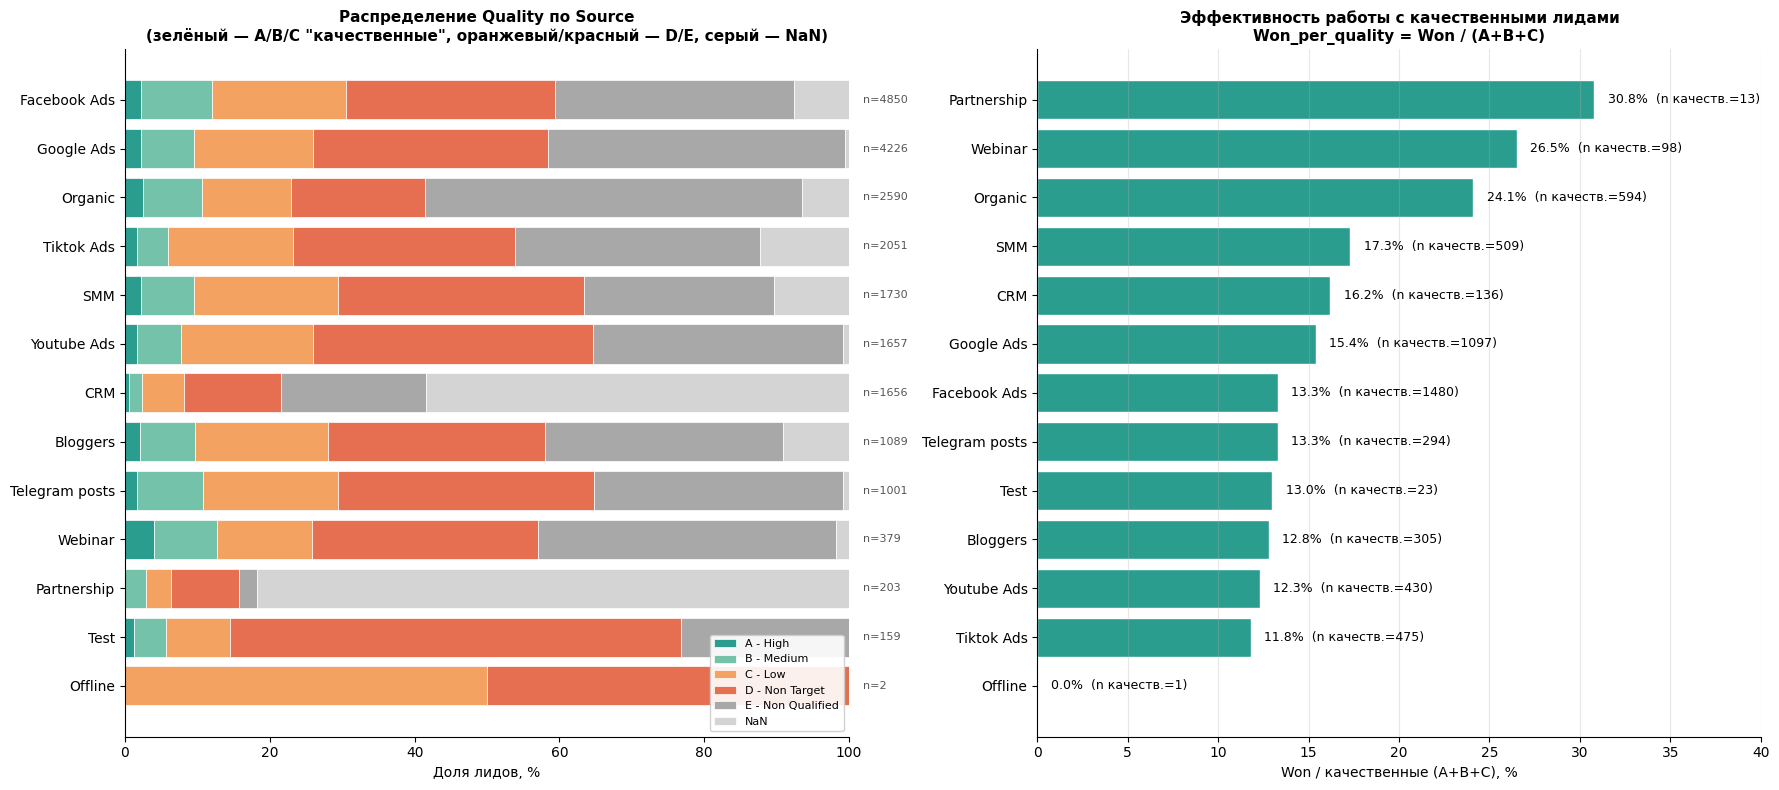

In [37]:
# === Left chart data: Quality distribution by Source ===
quality_order = ['A - High', 'B - Medium', 'C - Low',
                 'D - Non Target', 'E - Non Qualified']

ct = pd.crosstab(deals['Source'], deals['Quality'], dropna=False, normalize='index') * 100

# Add NaN separately (crosstab skips it by default)
nan_share = (deals.groupby('Source')['Quality']
             .apply(lambda x: x.isna().mean()) * 100)
ct['NaN'] = nan_share

ct = ct[quality_order + ['NaN']]
ct = ct.loc[source_stats.index]

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# --- Left: stacked bar Quality by Source ---
colors_quality = ['#2a9d8f', '#73c2a9', '#f4a261', '#e76f51', '#a8a8a8', '#d4d4d4']

bottom = pd.Series([0] * len(ct), index=ct.index)
for col, color in zip(ct.columns, colors_quality):
    axes[0].barh(ct.index, ct[col], left=bottom, color=color,
                 label=col, edgecolor='white', linewidth=0.5)
    bottom += ct[col]

axes[0].set_xlabel('Share of leads, %')
axes[0].set_title('Quality distribution by Source\n'
                  '(green — A/B/C "quality", orange/red — D/E, gray — NaN)',
                  fontsize=11, fontweight='bold')
axes[0].set_xlim(0, 100)
axes[0].legend(loc='lower right', fontsize=8, framealpha=0.9)
axes[0].invert_yaxis()
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

for i, src in enumerate(ct.index):
    axes[0].text(101, i, f'  n={int(source_stats.loc[src, "leads"])}',
                 va='center', fontsize=8, color='#555')

# --- Right: bar by won_per_quality_% ---
data_right = source_stats.sort_values('won_per_quality_%', ascending=True)

bars = axes[1].barh(data_right.index, data_right['won_per_quality_%'],
                    color='#2a9d8f', edgecolor='white')

for i, (src, row) in enumerate(data_right.iterrows()):
    axes[1].text(row['won_per_quality_%'] + 0.3, i,
                 f'  {row["won_per_quality_%"]:.1f}%  (quality n={int(row["quality_good"])})',
                 va='center', fontsize=9)

axes[1].set_xlabel('Won / quality (A+B+C), %')
axes[1].set_title('Effectiveness with quality leads\nWon_per_quality = Won / (A+B+C)',
                  fontsize=11, fontweight='bold')
axes[1].set_xlim(0, data_right['won_per_quality_%'].max() * 1.30)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

Left chart:
- CRM has anomalously many NaN (~60% gray/light) — CRM leads often aren't re-scored. Likely when reactivating an old lead, the manager doesn't reassess it.
- Partnership and Offline — almost all D/E/NaN. On the right, Partnership shows 30.8% won_per_quality — but the base is tiny: only 13 quality leads out of 203.
- The dark-green part (Quality A) is wider for Webinar than for others.
- TikTok, Bloggers, Youtube — visually similar structure, lots of "red" (D) and "gray" (E), explaining their low won_per_quality.

## 3. Sales performance — revenue

Effectiveness of campaigns by total sales (deal owners and conversion are covered above and in the dashboard; revenue is below).

### Revenue by campaign

In [38]:
campaign_revenue = deals.groupby('Campaign').agg(
    leads=('Id', 'count'),
    won=('is_won_confirmed', 'sum'),
    revenue=('revenue_actual', 'sum'),
).round(0)

# AOV — average payment per Won deal
campaign_revenue['aov'] = (
    campaign_revenue['revenue'] / campaign_revenue['won']
).round(0)

# Top-15 campaigns by revenue (excl. No Campaign for correctness)
top_revenue = (campaign_revenue[campaign_revenue.index != 'No Campaign']
               .sort_values('revenue', ascending=False)
               .head(15))

print("Top-15 campaigns by revenue:")
print(top_revenue)

print(f"\nTotal Won revenue: €{campaign_revenue['revenue'].sum():,.0f}")
print(f"Of it on 'No Campaign': €{campaign_revenue.loc['No Campaign', 'revenue']:,.0f}")

Топ-15 кампаний по выручке:
                                   leads  won   revenue     aov
Campaign                                                       
performancemax_digitalmarkt_ru_DE   2653  109  485650.0  4456.0
02.07.23wide_DE                      975   52  266600.0  5127.0
youtube_shorts_DE                   1635   53  215550.0  4067.0
12.07.2023wide_DE                   1575   48  193800.0  4038.0
03.07.23women                        612   30  146600.0  4887.0
Dis_DE                               581   29  146250.0  5043.0
07.07.23LAL_DE                       542   28  144800.0  5171.0
12.09.23interests_Uxui_DE            531   26  133600.0  5138.0
04.07.23recentlymoved_DE             750   30  111100.0  3703.0
24.09.23retargeting_DE               479   17   67000.0  3941.0
BloggerShina_DE                      246   11   54150.0  4923.0
brand_search_eng_DE                  168   15   52050.0  3470.0
work_DE                              317    9   44100.0  4900.0
mu_DE       

### Findings

AOV stays in a narrow band of €3,500-5,200 — typical course price.

No Campaign brought €1.03M of €3.56M — 28.8% of total revenue. Examined by Source next.

In [39]:
no_camp_revenue = (deals[(deals['Campaign'] == 'No Campaign')
                          & deals['is_won_confirmed']]
                   .groupby('Source')['revenue_actual']
                   .agg(['sum', 'count'])
                   .sort_values('sum', ascending=False))
no_camp_revenue.columns = ['revenue', 'won']
print(no_camp_revenue)

                 revenue  won
Source                       
Organic         606100.0  142
SMM             275950.0   80
Bloggers         48100.0   14
Webinar          31600.0    8
Telegram posts   28500.0    6
Facebook Ads     17200.0    4
CRM               9200.0    6
Test              6200.0    2
Partnership       3100.0    2


### Findings

1. Organic and SMM have no ad campaign, so a missing campaign is expected there. For the rest — recommendation for the client: check why the data wasn't filled in.
2. Top-3 by revenue aren't always top-3 by volume:
   - performancemax_digitalmarkt_ru_DE — €486k (also the largest by volume)
   - 02.07.23wide_DE — €267k (4th by volume), fewer leads than the top-2 but more revenue than youtube_shorts_DE — due to higher CR (5.3% vs 3.2%) and stable AOV.
   - youtube_shorts_DE — €216k — brings many leads (1,635) but low CR, so revenue is lower.

#### Chart

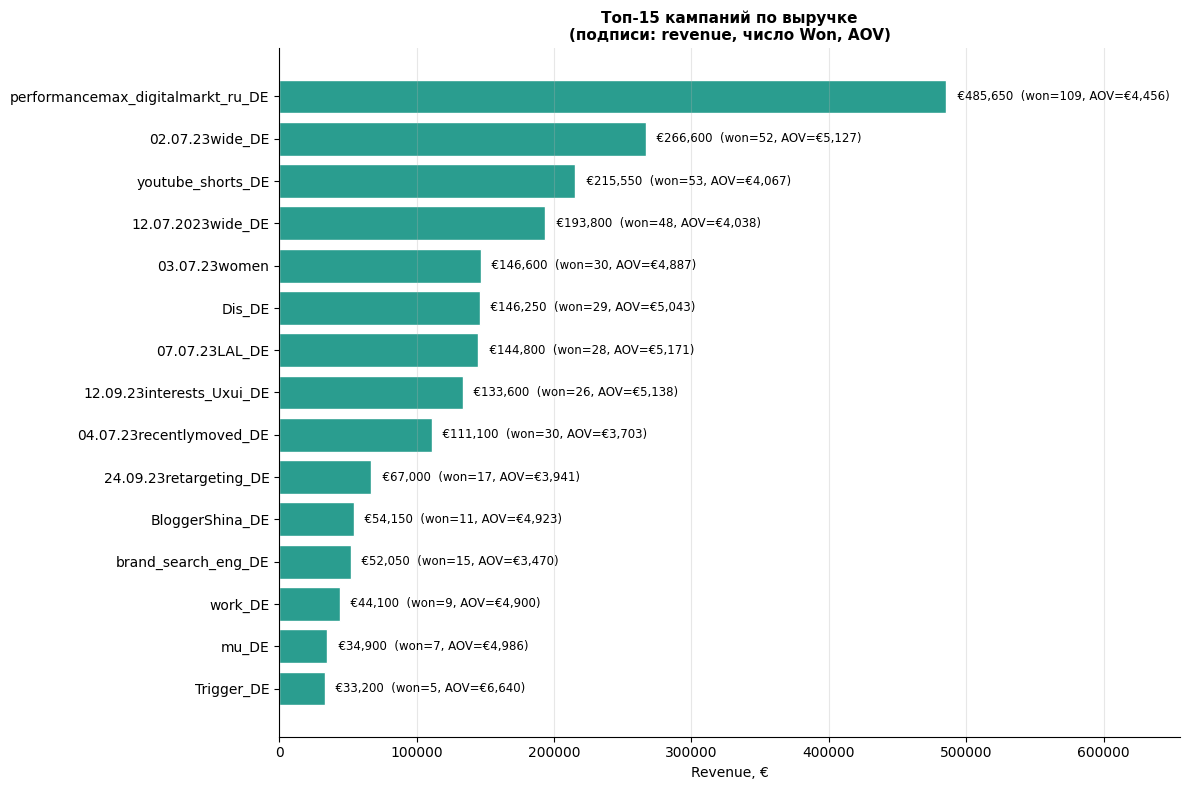

In [40]:
# Top-15 for the chart (ascending — horizontal bar)
top_for_plot = top_revenue.sort_values('revenue', ascending=True)

fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.barh(top_for_plot.index, top_for_plot['revenue'], color='#2a9d8f', edgecolor='white')

# Labels: revenue + Won + AOV
for i, (camp, row) in enumerate(top_for_plot.iterrows()):
    label = f'  €{int(row["revenue"]):,}  (won={int(row["won"])}, AOV=€{int(row["aov"]):,})'
    ax.text(row['revenue'] + top_for_plot['revenue'].max() * 0.005, i, label, va='center', fontsize=8.5)

ax.set_xlabel('Revenue, €')
ax.set_title('Top-15 campaigns by revenue\n(labels: revenue, Won count, AOV)',
             fontsize=11, fontweight='bold')
ax.set_xlim(0, top_for_plot['revenue'].max() * 1.35)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()